# Prognoza liczby wypadków rowerowych w Chicago na kolejne lata

<div style="text-align: center;"><img src=".//Images//Chicago.png" alt="Chicago" width="400" height="120" style="margin: 10px; "/></div>

Celem analizy jest oszacowanie skali wypadków rowerowych w Chicago w kolejnych latach na podstawie dostępnych danych historycznych. Plik `chicago_bikes.xlsx` zawiera szczegółowe informacje o wypadkach z udziałem rowerzystów, w tym daty zdarzeń.

Zadanie: 
* wykonaj proste prognozowanie roczne (na kolejne lata)
* wykonaj prognozowanie miesięczne (1 rok do przodu)

## Prognoza za pomocą modelu Holt-Winters (bez sezonowości)

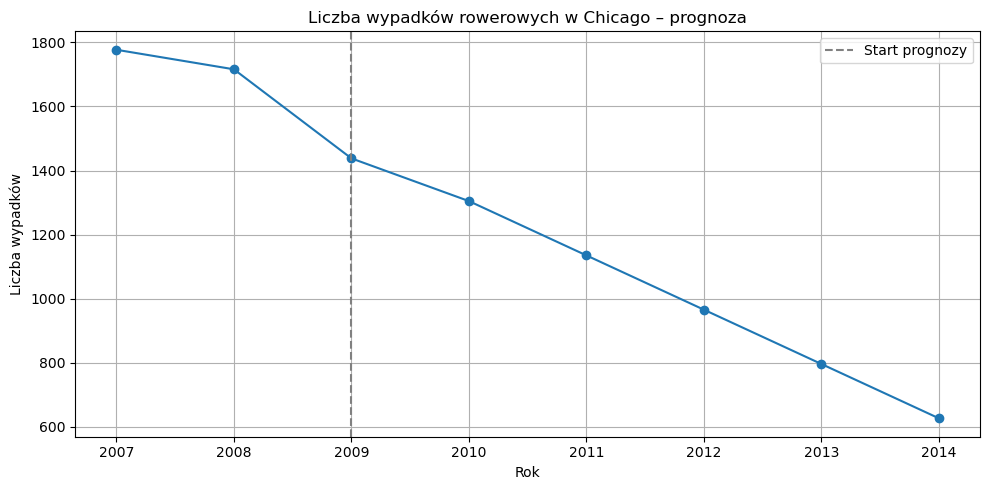

   Year    Accidents
0  2007  1777.000000
1  2008  1716.000000
2  2009  1438.000000
3  2010  1304.665453
4  2011  1135.164972
5  2012   965.664491
6  2013   796.164011
7  2014   626.663530


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Wczytanie danych z pliku Excel
file_path = "./Dane/chicago_bikes.xlsx"  
xls = pd.ExcelFile(file_path)

# Wczytanie danych z arkusza 'Arkusz2'
df = pd.read_excel(xls, sheet_name="Arkusz2")

# Konwersja kolumny 'Date' na format datetime i wyodrębnienie roku
df["Date"] = pd.to_datetime(df["Date"], format="%m-%d-%y")
df["Year"] = df["Date"].dt.year

# Grupowanie danych według roku i zliczanie liczby wypadków
accidents_per_year = df.groupby("Year").size().reset_index(name="Accidents")

# Model prognozujący liczbę wypadków – metoda Holt-Winters (bez sezonowości)
model = ExponentialSmoothing(
    accidents_per_year["Accidents"],
    trend="add",
    seasonal=None,
    initialization_method="estimated"
).fit()

# Prognoza na kolejne 5 lat
forecast_years = pd.Series(range(accidents_per_year["Year"].max() + 1, accidents_per_year["Year"].max() + 6))
forecast = model.forecast(steps=5)

# Połączenie danych historycznych i prognozowanych
forecast_df = pd.DataFrame({
    "Year": list(accidents_per_year["Year"]) + list(forecast_years),
    "Accidents": list(accidents_per_year["Accidents"]) + list(forecast)
})

# Wykres
plt.figure(figsize=(10, 5))
plt.plot(forecast_df["Year"], forecast_df["Accidents"], marker='o')
plt.axvline(x=accidents_per_year["Year"].max(), color='gray', linestyle='--', label='Start prognozy')
plt.title("Liczba wypadków rowerowych w Chicago – prognoza")
plt.xlabel("Rok")
plt.ylabel("Liczba wypadków")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Wyświetlenie wyników
print(forecast_df)

----

Zastosowano model wygładzania wykładniczego Holt-Wintersa (z trendem liniowym, bez sezonowości), który dobrze sprawdza się przy krótkich szeregach czasowych.

Prognoza sugeruje wyraźny trend spadkowy, jednak należy pamiętać, że została oparta na bardzo krótkim szeregu czasowym (tylko 3 lata), co ogranicza jej wiarygodność. Dodanie kolejnych lat do analizy pozwoliłoby na dokładniejsze oszacowania i lepsze dopasowanie modelu.

----

## Prognoza za pomocą modelu Holt-Winters (z sezonowością)

**Model wygładzania wykładniczego Holt-Wintersa** (czyli model wygładzania podwójnego lub potrójnego) **może uwzględniać sezonowość** – i to właśnie odróżnia go od prostych metod wygładzania.

W `statsmodels` można ustawić to poprzez parametry `seasonal` oraz `seasonal_periods`.

---

Jeśli masz dane miesięczne i chcesz uwzględnić sezonowość roczną (okres = 12 miesięcy), konfiguracja może wyglądać tak:

```python
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(
    series,                     # np. monthly['Accidents']
    trend='add',                # lub 'mul', jeśli dane wykazują wzrost/wahania proporcjonalne
    seasonal='add',             # lub 'mul' przy sezonowości proporcjonalnej
    seasonal_periods=12         # np. 12 miesięcy = 1 rok sezonowości
).fit()
```

---

Uwagi:

* `trend='add'` — zakłada liniowy trend wzrostu/spadku;
* `seasonal='add'` — zakłada addytywną sezonowość (każdy sezonowy komponent ma stały wpływ);
* `seasonal_periods=12` — okres sezonowości (dla miesięcznych danych: 12 miesięcy = 1 rok).

---

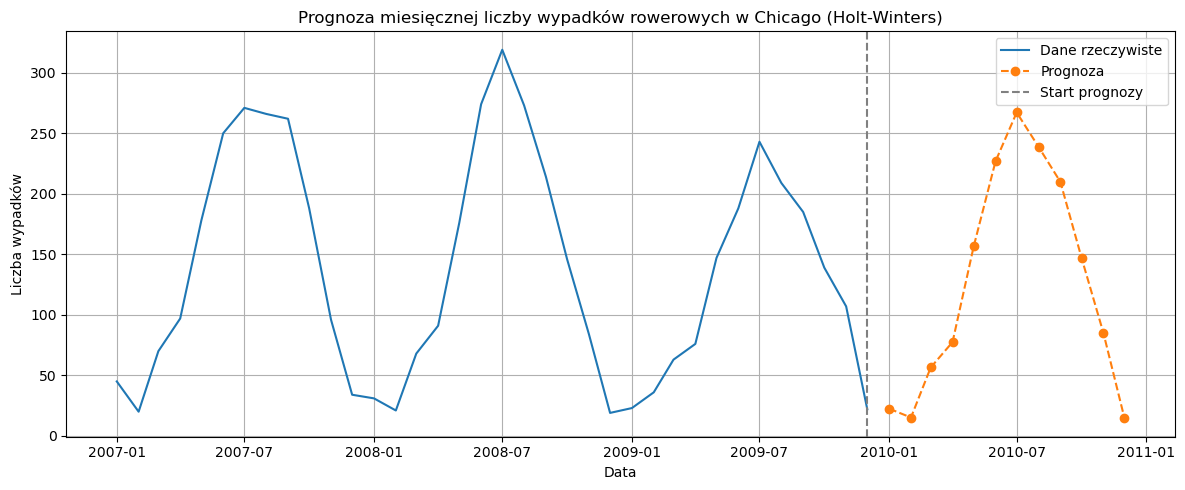

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Wczytanie danych z pliku Excel
file_path = "./Dane/chicago_bikes.xlsx"  
xls = pd.ExcelFile(file_path)

# Wczytanie danych z arkusza 'Arkusz2'
df = pd.read_excel(xls, sheet_name="Arkusz2")

# Konwersja kolumny 'Date' na format datetime i ustawienie indeksu
df["Date"] = pd.to_datetime(df["Date"], format="%m-%d-%y")
df.set_index("Date", inplace=True)

# Grupowanie danych miesięcznych (liczba wypadków na miesiąc)
monthly = df.resample("MS").size().to_frame(name="Accidents")
monthly.index.freq = "MS"

# Dopasowanie modelu Holt-Wintersa z trendem i sezonowością (okres 12 miesięcy)
model = ExponentialSmoothing(
    monthly["Accidents"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

# Prognoza na kolejne 12 miesięcy
forecast = model.forecast(12)

# Łączenie danych historycznych z prognozowanymi
forecast_df = pd.concat([monthly, forecast.to_frame(name="Accidents_forecast")], axis=1)

# Wykres
plt.figure(figsize=(12, 5))
plt.plot(monthly.index, monthly["Accidents"], label="Dane rzeczywiste")
plt.plot(forecast.index, forecast, label="Prognoza", linestyle="--", marker="o")
plt.axvline(x=monthly.index.max(), color='gray', linestyle='--', label='Start prognozy')
plt.title("Prognoza miesięcznej liczby wypadków rowerowych w Chicago (Holt-Winters)")
plt.xlabel("Data")
plt.ylabel("Liczba wypadków")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [3]:
# Wyświetlenie wyników prognozy
print(forecast)

2010-01-01     22.508635
2010-02-01     15.178869
2010-03-01     56.517598
2010-04-01     77.520751
2010-05-01    156.523223
2010-06-01    226.860201
2010-07-01    267.195562
2010-08-01    238.864482
2010-09-01    209.868297
2010-10-01    147.202671
2010-11-01     85.209564
2010-12-01     14.546415
Freq: MS, dtype: float64


## Prognoza miesięcznej liczby wypadków z uwzględnieniem sezonowości (model SARIMA)

            Accidents
Date                 
2007-01-01         45
2007-02-01         20
2007-03-01         70
2007-04-01         97
2007-05-01        178


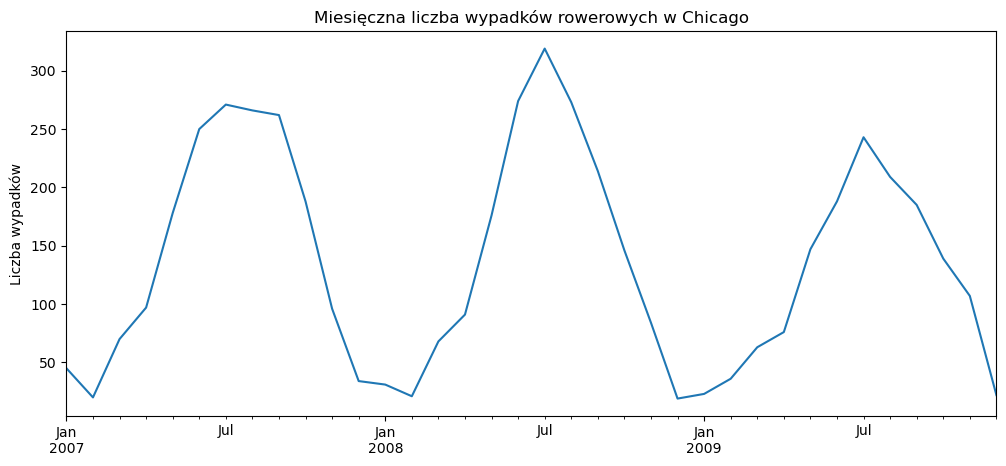

In [4]:
import pandas as pd
import numpy as np
%matplotlib inline

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf 
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima import auto_arima                              
from sklearn.metrics import mean_squared_error
from statsmodels.tools.eval_measures import rmse

import warnings
warnings.filterwarnings("ignore")

# Wczytaj dane
df = pd.read_excel('./Dane/chicago_bikes.xlsx', sheet_name='Arkusz2')

# Konwersja daty i ustawienie indeksu
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%y')
df.set_index('Date', inplace=True)

# Grupowanie miesięczne
monthly = df.resample('MS').size().to_frame(name='Accidents')
monthly.index.freq = 'MS'
print(monthly.head())

# Wizualizacja danych
title = 'Miesięczna liczba wypadków rowerowych w Chicago'
ylabel = 'Liczba wypadków'
xlabel = ''

ax = monthly['Accidents'].plot(figsize=(12,5), title=title)
ax.set(xlabel=xlabel, ylabel=ylabel)
ax.autoscale(axis='x', tight=True)

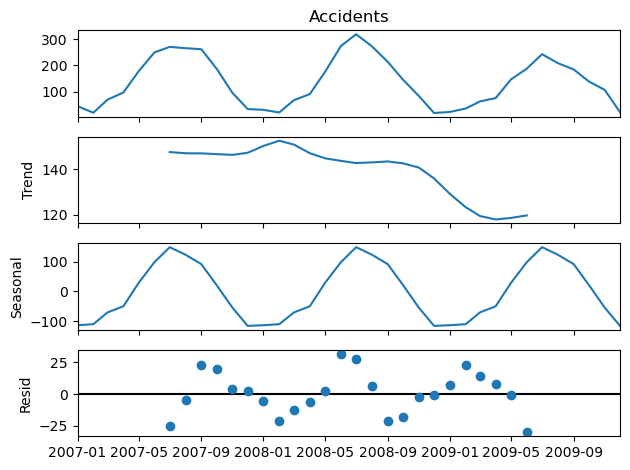

In [5]:
# Dekompozycja
result = seasonal_decompose(monthly['Accidents'], model='add')
result.plot();

In [6]:
# Auto ARIMA – dopasowanie najlepszego modelu SARIMA
auto_arima(monthly['Accidents'], seasonal=True, m=12).summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                   36
Model:             SARIMAX(0, 0, 2)x(0, 1, [], 12)   Log Likelihood                -106.694
Date:                             Fri, 30 May 2025   AIC                            221.389
Time:                                     08:34:53   BIC                            226.101
Sample:                                 01-01-2007   HQIC                           222.639
                                      - 12-01-2009                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    -14.7803     14.822     -0.997      0.319     -43.831      14.270
ma.L1          1.0232      0.269      3.800      0.000       0.496       1.551
ma.L2          0.4298      0.296      1.452      0.146      -0.150       1.010
sigma2       406.0147    145.829      2.784      0.005     120.195     691.834
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 4.55
Prob(Q):                              0.86   Prob(JB):                         0.10
Heteroskedasticity (H):               2.28   Skew:                            -0.94
Prob(H) (two-sided):                  0.27   Kurtosis:                         4.00
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

----

**Na podstawie wyników dopasowanego modelu SARIMAX, prawidłowe parametry są następujące**:

`order = (0, 0, 2)`
(czyli: brak składnika autoregresyjnego (AR), brak różnicowania (d=0), dwa opóźnienia składnika średniej ruchomej (MA)).

`seasonal_order = (0, 1, 0, 12)`
(czyli: brak sezonowego AR, jedno sezonowe różnicowanie, brak sezonowego MA, okres sezonowości = 12 miesięcy).

----

In [7]:
# Podział na dane treningowe i testowe (ostatnie 12 miesięcy jako test)
train = monthly.iloc[:-12]
test = monthly.iloc[-12:]

# Trening modelu SARIMA
model = SARIMAX(train['Accidents'], order=(0,0,2), seasonal_order=(0,1,0,12))
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                           Accidents   No. Observations:                   24
Model:             SARIMAX(0, 0, 2)x(0, 1, [], 12)   Log Likelihood                 -48.914
Date:                             Fri, 30 May 2025   AIC                            103.827
Time:                                     08:34:53   BIC                            105.282
Sample:                                 01-01-2007   HQIC                           103.289
                                      - 12-01-2008                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          1.9056     16.533      0.115      0.908     -30.498      34.309
ma.L2          0.9897     17.016      0.058      0.954     -32.361      34.340
sigma2       121.0310   2070.423      0.058      0.953   -3936.924    4178.986
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):                 0.09
Prob(Q):                              0.82   Prob(JB):                         0.96
Heteroskedasticity (H):               2.56   Skew:                             0.21
Prob(H) (two-sided):                  0.38   Kurtosis:                         3.07
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

SARIMA(0,1,0)(2,0,0,12) MSE Error: 1742.893543
SARIMA(0,1,0)(2,0,0,12) RMSE Error: 41.74797651


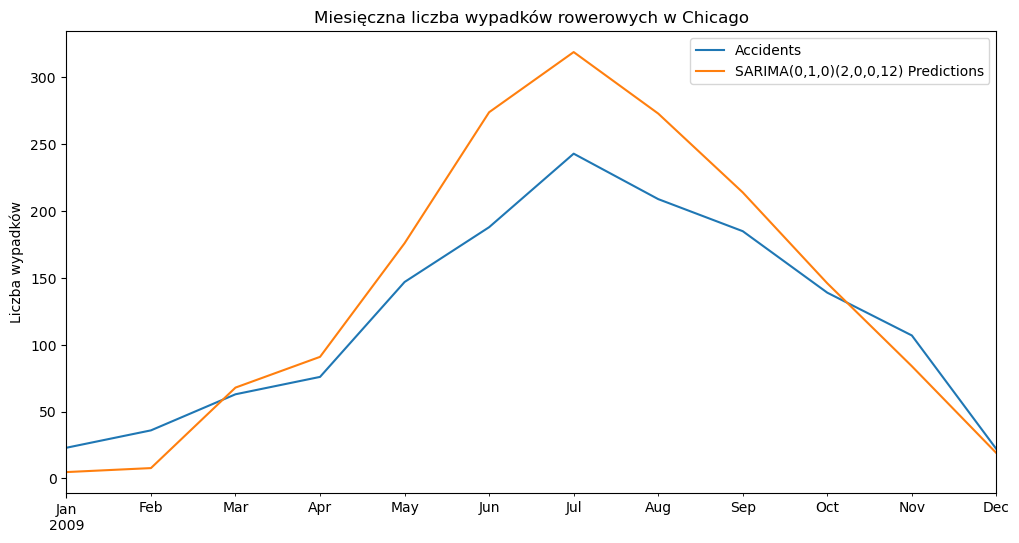

In [8]:
# Prognoza na okres testowy
start = len(train)
end = len(train) + len(test) - 1
predictions = results.predict(start=start, end=end, dynamic=False, typ='levels').rename('SARIMA(0,1,0)(2,0,0,12) Predictions')

# Wykres test vs predykcja
title = 'Miesięczna liczba wypadków rowerowych w Chicago'
ylabel = 'Liczba wypadków'
xlabel = ''

ax = test['Accidents'].plot(legend=True, figsize=(12,6), title=title)
predictions.plot(legend=True)
ax.set(xlabel=xlabel, ylabel=ylabel)
ax.autoscale(axis='x', tight=True)

# Błąd prognozy
error1 = mean_squared_error(test['Accidents'], predictions)
error2 = rmse(test['Accidents'], predictions)
print(f'SARIMA(0,1,0)(2,0,0,12) MSE Error: {error1:11.10}')
print(f'SARIMA(0,1,0)(2,0,0,12) RMSE Error: {error2:11.10}')

In [9]:
# Trenowanie na pełnym zbiorze i prognoza na 12 miesięcy w przód
model = SARIMAX(train['Accidents'], order=(0,0,2), seasonal_order=(0,1,0,12))
results = model.fit()
fcast = results.predict(len(monthly), len(monthly)+11, typ='levels').rename('SARIMA(0,0,2)(0,1,0,12) Forecast')

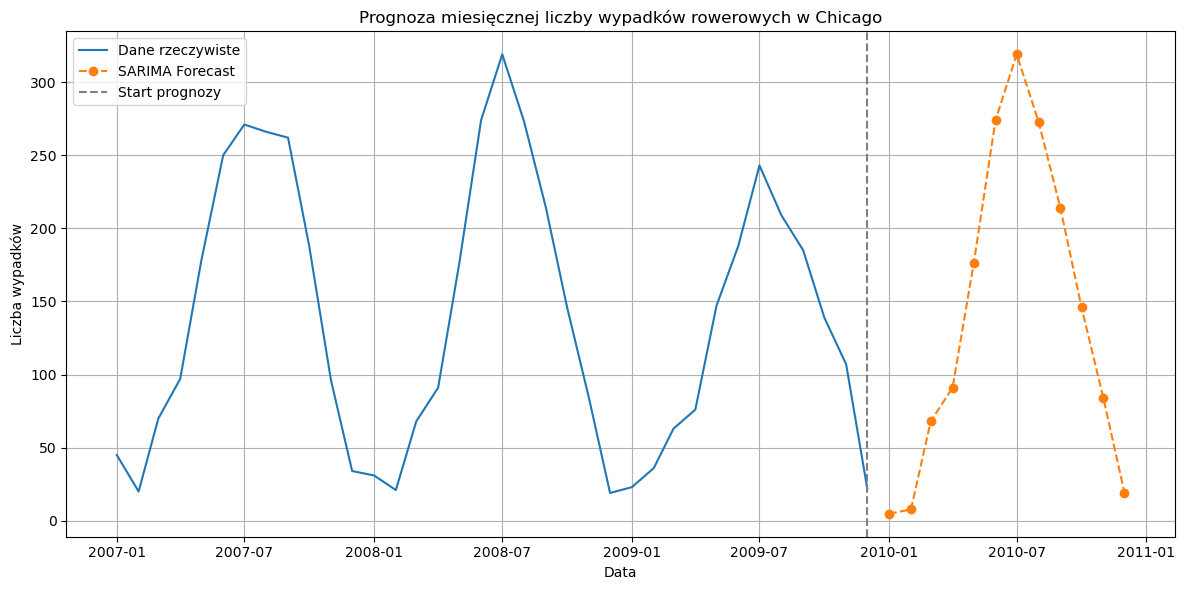

In [10]:
# Wykres prognozy
plt.figure(figsize=(12, 6))
plt.plot(monthly.index, monthly['Accidents'], label='Dane rzeczywiste')
plt.plot(fcast.index, fcast.values, label='SARIMA Forecast', linestyle='--', marker='o')
plt.axvline(x=monthly.index.max(), color='gray', linestyle='--', label='Start prognozy')
plt.title('Prognoza miesięcznej liczby wypadków rowerowych w Chicago')
plt.xlabel('Data')
plt.ylabel('Liczba wypadków')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Podsumowanie

**Holt-Winters** i **SARIMA** to modele do prognozowania szeregów czasowych:

* **Holt-Winters** (ETS) lepiej sprawdza się przy **prostych, regularnych danych z wyraźnym trendem i sezonowością**. Jest łatwiejszy w interpretacji i szybki w użyciu.
* **SARIMA** jest bardziej **elastyczny i statystycznie zaawansowany** – uwzględnia opóźnienia, szum i pozwala na testowanie dopasowania modelu. Dobrze radzi sobie z bardziej złożonymi strukturami czasowymi.

**W skrócie**:
- **Holt-Winters** – prosty, przejrzysty, dobry do gładkich danych.
- **SARIMA** – złożony, precyzyjny, dobry do analizy statystycznej i prognoz z niepewnością.

# Do samodzielnej analizy

*Przenalizuj zmienność w ciągu tygodnia i w ciągu dnia.*